<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana1/QuejasAmbientales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Como cargar el drive en python, comment
# Sintaxis -> una forma de escribir

from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana1/')

In [3]:
import pandas as pd
datos = pd.read_csv('Data/QuejasAmbientales.csv')

In [4]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo
0,Bosques,Telefónico,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
1,Aguas,Pagina Web,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021
2,Bosques,Pagina Web,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
3,Bosques,Telefónico,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021
4,Paramo,Pagina Web,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021
...,...,...,...,...,...,...
1800,Valles,Correo electrónico,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021
1801,Valles,Correo electrónico,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021
1802,Valles,Correo electrónico,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021
1803,Aguas,Correo electrónico,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021


In [5]:
##### La paqueteria!!!!
import matplotlib.pyplot as plt

#
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier # Problema de classificacion

from sklearn.tree import plot_tree

# Necesitamos metricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
datos.keys()

Index(['REGIONAL', 'MEDIO DE  RECEPCION', 'TIPO DE AFECTACION',
       'RECURSO AFECTADO', 'MUNICIPIO', 'Periodo'],
      dtype='object')

In [7]:
columnas_texto = [
    "REGIONAL",
    "MEDIO DE  RECEPCION",
    "TIPO DE AFECTACION",
    "RECURSO AFECTADO",
    "MUNICIPIO"
]

In [8]:
for columna in columnas_texto:

  datos[columna] = datos[columna].str.strip()
  # Quitar los espacios al comienzo y al final # Mineria

  # Todo en mayusculas
  datos[columna] = datos[columna].str.upper()


In [9]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo
0,BOSQUES,TELEFÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
1,AGUAS,PAGINA WEB,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021
2,BOSQUES,PAGINA WEB,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
3,BOSQUES,TELEFÓNICO,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021
4,PARAMO,PAGINA WEB,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021
...,...,...,...,...,...,...
1800,VALLES,CORREO ELECTRÓNICO,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021
1801,VALLES,CORREO ELECTRÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021
1802,VALLES,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021
1803,AGUAS,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021


In [10]:
# Es la variable a predecir
datos['ES_TELEFONICA'] = (datos['MEDIO DE  RECEPCION'] == "TELEFÓNICO").astype(int)

In [11]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo,ES_TELEFONICA
0,BOSQUES,TELEFÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021,1
1,AGUAS,PAGINA WEB,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021,0
2,BOSQUES,PAGINA WEB,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021,0
3,BOSQUES,TELEFÓNICO,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021,1
4,PARAMO,PAGINA WEB,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021,0
...,...,...,...,...,...,...,...
1800,VALLES,CORREO ELECTRÓNICO,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021,0
1801,VALLES,CORREO ELECTRÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021,0
1802,VALLES,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021,0
1803,AGUAS,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021,0


In [12]:
datos['ES_TELEFONICA'].value_counts()

,count
ES_TELEFONICA,
1,971
0,834


In [13]:
datos['ES_TELEFONICA'].value_counts( normalize = True )

,proportion
ES_TELEFONICA,
1,0.53795
0,0.46205


In [14]:
# Vamos a preparar las variables explicativas
variables_entrada = [
    "REGIONAL",
    "TIPO DE AFECTACION",
    "RECURSO AFECTADO",
    "MUNICIPIO"
]

In [15]:
# la informacion de entrada al modelo
X = datos[variables_entrada]
X

,REGIONAL,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO
0,BOSQUES,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS
1,AGUAS,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL
2,BOSQUES,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS
3,BOSQUES,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO
4,PARAMO,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN
...,...,...,...,...
1800,VALLES,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE
1801,VALLES,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE
1802,VALLES,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA
1803,AGUAS,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ


In [16]:
# la respuesta que queremos predecir
Y = datos['ES_TELEFONICA']

In [17]:
Y

,ES_TELEFONICA
0,1
1,0
2,0
3,1
4,0
...,...
1800,0
1801,0
1802,0
1803,0


In [18]:
# Codificacion -> one-hot encoding
X = pd.get_dummies(X, dtype=int)
X

,REGIONAL_AGUAS,REGIONAL_BOSQUES,REGIONAL_PARAMO,REGIONAL_PORCE,REGIONAL_VALLES,TIPO DE AFECTACION_CONFLICTOS POR USO DEL AGUA,TIPO DE AFECTACION_CONTAMINACION DEL AGUA,TIPO DE AFECTACION_CONTAMINACIÓN POR VERTIMIENTOS,TIPO DE AFECTACION_DESCORTEZADO DE ÁRBOLES,TIPO DE AFECTACION_EMISION ATMOSFÉRICA,...,MUNICIPIO_PUERTO TRIUNFO,MUNICIPIO_RIONEGRO,MUNICIPIO_SAN CARLOS,MUNICIPIO_SAN FRANCISCO,MUNICIPIO_SAN LUIS,MUNICIPIO_SAN RAFAEL,MUNICIPIO_SAN ROQUE,MUNICIPIO_SAN VICENTE,MUNICIPIO_SANTO DOMINGO,MUNICIPIO_SONSÓN
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1801,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1802,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1803,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
# Dividir los datos en entrenamiento y prueba
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# random_state=42, reproducibilidad

In [20]:
Y.value_counts()

,count
ES_TELEFONICA,
1,971
0,834


In [31]:
# Vamos a definir el modelo
modelo = DecisionTreeClassifier(
    max_depth=4, # Un hiperparametro -> toca optimizarlo
    min_samples_leaf=10, # Un hiperparametro
    random_state=42
)

In [32]:
# Entrenar el modelo con los datos
modelo.fit(X_entrenamiento, Y_entrenamiento)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

In [33]:
predicciones = modelo.predict(X_prueba)
predicciones

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,

In [34]:
# Necesitamos el concepto de metrica
exactitud_modelo = accuracy_score(Y_prueba, predicciones)
exactitud_modelo

0.6094182825484764

In [35]:
#QUe mejora tuvimos
clase_mayoritaria = Y_entrenamiento.mode()[0]
clase_mayoritaria

np.int64(1)

In [36]:
prediccion_basica = [clase_mayoritaria] * len(Y_prueba)

exactitud_basica = accuracy_score(Y_prueba, prediccion_basica)
exactitud_basica

0.5373961218836565

In [37]:
mejora = exactitud_modelo - exactitud_basica
mejora

0.07202216066481992

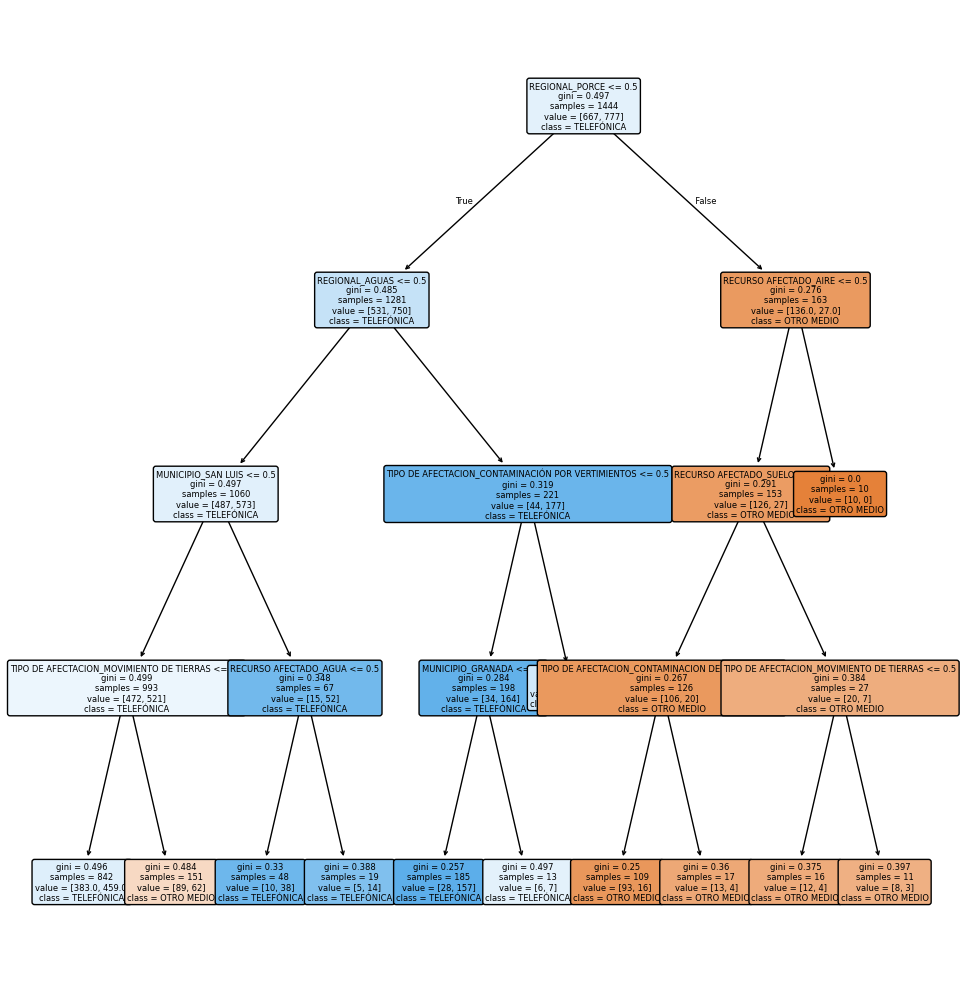

In [41]:
# Como dibujar el modelo
plt.figure( figsize=(10, 10) )
plot_tree(modelo,
          feature_names=X.columns,
          filled=True,
          class_names=["OTRO MEDIO", "TELEFÓNICA"],
          rounded=True,
          #impurity=False,
          fontsize=6)
plt.tight_layout()
plt.show()

In [44]:
importancias = pd.DataFrame(modelo.feature_importances_, index=X.columns)
importancias.head(10)

,0
REGIONAL_AGUAS,0.261271
REGIONAL_BOSQUES,0.000000
REGIONAL_PARAMO,0.000000
REGIONAL_PORCE,0.537270
REGIONAL_VALLES,0.000000
TIPO DE AFECTACION_CONFLICTOS POR USO DEL AGUA,0.000000
TIPO DE AFECTACION_CONTAMINACION DEL AGUA,0.002428
TIPO DE AFECTACION_CONTAMINACIÓN POR VERTIMIENTOS,0.030060
TIPO DE AFECTACION_DESCORTEZADO DE ÁRBOLES,0.000000
TIPO DE AFECTACION_EMISION ATMOSFÉRICA,0.000000


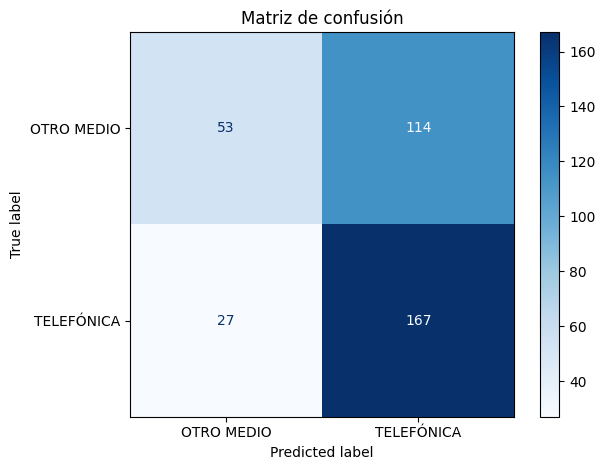

In [45]:
ConfusionMatrixDisplay.from_predictions(
    Y_prueba,
    predicciones,
    display_labels=["OTRO MEDIO", "TELEFÓNICA"],
    cmap="Blues"
)

plt.title("Matriz de confusión")

plt.tight_layout()

plt.show()
